In [1]:
import sys
sys.path.append("src")

import matplotlib.pyplot as plt
import numpy as np  # arrays, linear algebra, numerical computing
from qutip import Bloch  # visualization of single-qubit states (Bloch sphere)  
import quantum_error_corrections as qec #  # custom quantum dynamics package

### Bloch Sphere Visualization of Quantum Noise Channels

Bit lip channels affect the qubit states |0⟩ and |+⟩. Green arrows represent the original states, and red arrows represent the states after the noise channel.

 Channels on a register

we will now consider single qubit channels which act on qubits that are part of a register. 

#### (a) Single qubit channels in an n-bit register

Build Kraus operators for a given channel that act on qubit $i$ within a register of $n$ qubits. The unitary single qubit gates considered on Problem Set 2 are a subclass of these.

Hints: Recall that that if we want to apply a single qubit gate in this formalism, we can do so in the same way we apply the Kraus operators, e.g., if we want to apply a Hadamard gate, the channel would be 
$$\mathcal{E}(\rho) = H\rho H^\dagger.$$

Build your single quubit channel acting on the n-qubit register by creating a list of single qubit gates acting on the n-qubit register. That is, create the single qubit Kraus operators acting on the n-qubit register, then use these to create the channel.

Test your function on a few states where we already know the result, e.g., apply the Hadamard *channel* to the $|0\rangle$ state. 

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.9486833+0.j, 0.       +0.j],
       [0.       +0.j, 0.9486833+0.j]]), array([[0.29215636+0.j        , 0.        -0.12101513j],
       [0.        -0.12101513j, 0.29215636+0.j        ]])]

Density matrix after X channel:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

initial Bloch vector:
 [1. 0. 0.]
Bloch vector after X channel:
 [1. 0. 0.]


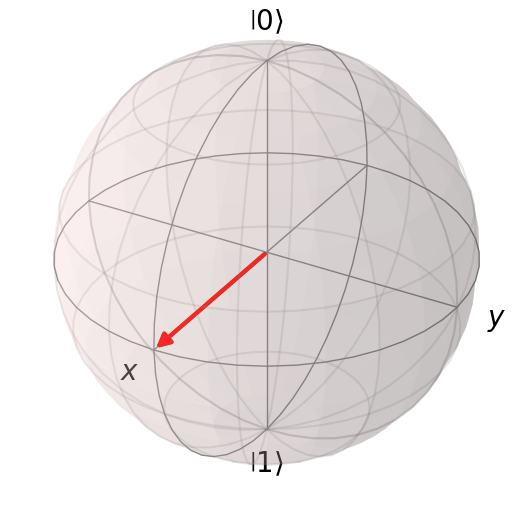

In [2]:
# Parameters
theta = np.pi / 4  
p = 0.1           
n = [1, 0, 0]    

# Initial state 
psi = qec.operators.ket_plus()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)

# Print Kraus operators and resulting state
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
# Compute Bloch vectors
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)

print("initial Bloch vector:\n", v_initial)
print("Bloch vector after X channel:\n", v_x)

# Visualize on Bloch sphere
b = Bloch()
b.vector_color = ['green', 'red']  # green = original, red = after channel
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |+>"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.50602966+0.j        , 0.        -0.20960435j],
       [0.        -0.20960435j, 0.50602966+0.j        ]])]

Density matrix after X channel:
 [[ 0.5+0.j -0.5+0.j]
 [-0.5+0.j  0.5+0.j]]

initial Bloch vector:
 [-1.  0.  0.]
Bloch vector after X channel:
 [-1.  0.  0.]


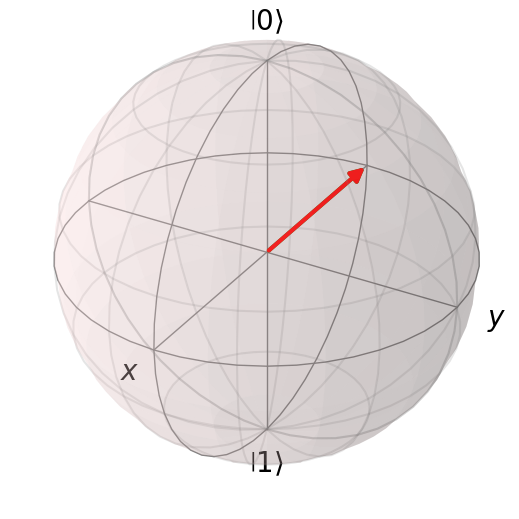

In [3]:
theta = np.pi / 4  
p = 0.3           
n = [1, 0, 0]   

psi = qec.operators.ket_minus()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x) 
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:\n", v_initial)
print("Bloch vector after X channel:\n", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |->"
b.show()

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.70710678+0.j, 0.        +0.j],
       [0.        +0.j, 0.70710678+0.j]]), array([[0.65328148+0.j        , 0.        -0.27059805j],
       [0.        -0.27059805j, 0.65328148+0.j        ]])]

Density matrix after X channel:
 [[0.9267767+0.j        0.       +0.1767767j]
 [0.       -0.1767767j 0.0732233+0.j       ]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after X channel: [ 0.         -0.35355339  0.85355339]


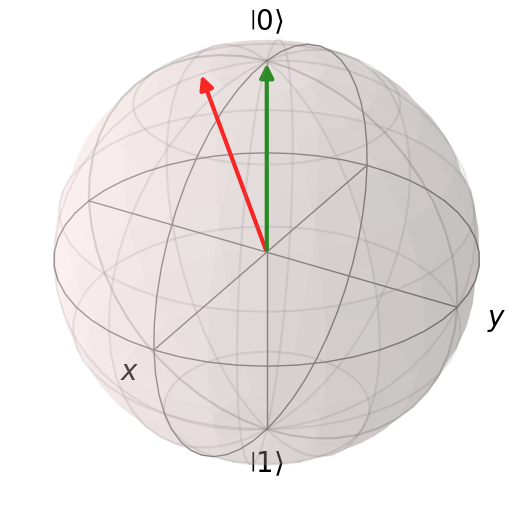

In [4]:
theta = np.pi / 4  
p = 0.5             
n = [1, 0, 0]    

psi = qec.operators.ket0()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi)
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |0>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.54772256+0.j, 0.        +0.j],
       [0.        +0.j, 0.54772256+0.j]]), array([[0.77297307+0.j        , 0.        -0.32017593j],
       [0.        -0.32017593j, 0.77297307+0.j        ]])]

Density matrix after X channel:
 [[0.10251263+0.j         0.        -0.24748737j]
 [0.        +0.24748737j 0.89748737+0.j        ]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after X channel: [ 0.          0.49497475 -0.79497475]


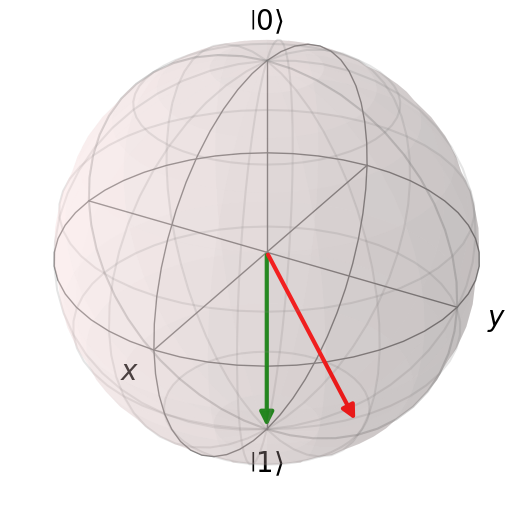

In [5]:
theta = np.pi / 4  
p = 0.7            
n = [1, 0, 0]    


psi = qec.operators.ket1()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |1>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908+0.j        , 0.        -0.36304538j],
       [0.        -0.36304538j, 0.87646908+0.j        ]])]

Density matrix after X channel:
 [[0.13180195+0.j         0.        -0.31819805j]
 [0.        +0.31819805j 0.86819805+0.j        ]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after X channel: [ 0.         0.6363961 -0.7363961]


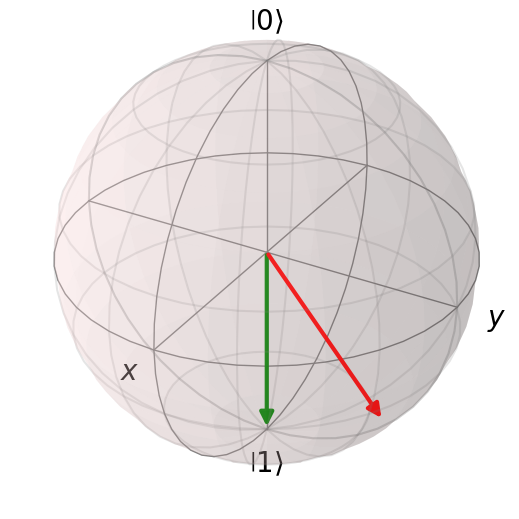

In [6]:
theta = np.pi / 4  
p = 0.9           
n = [1, 0, 0]    


psi = qec.operators.ket1()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |1>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.9486833+0.j, 0.       +0.j],
       [0.       +0.j, 0.9486833+0.j]]), array([[0.29215636+0.j        , 0.        -0.12101513j],
       [0.        -0.12101513j, 0.29215636+0.j        ]])]

Density matrix after X channel:
 [[0.01464466+0.j         0.        -0.03535534j]
 [0.        +0.03535534j 0.98535534+0.j        ]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after X channel: [ 0.          0.07071068 -0.97071068]


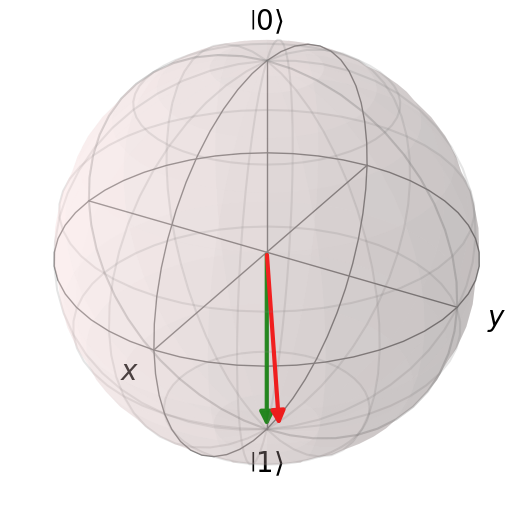

In [7]:
theta = np.pi / 4  
p = 0.1            
n = [1, 0, 0]    


psi = qec.operators.ket1()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |1>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X-axis:
 [[0.70710678+0.j         0.        -0.70710678j]
 [0.        -0.70710678j 0.70710678+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.67082039+0.j        , 0.        -0.67082039j],
       [0.        -0.67082039j, 0.67082039+0.j        ]])]

Density matrix after X channel:
 [[0.45+0.j   0.  -0.45j]
 [0.  +0.45j 0.55+0.j  ]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after X channel: [ 0.   0.9 -0.1]


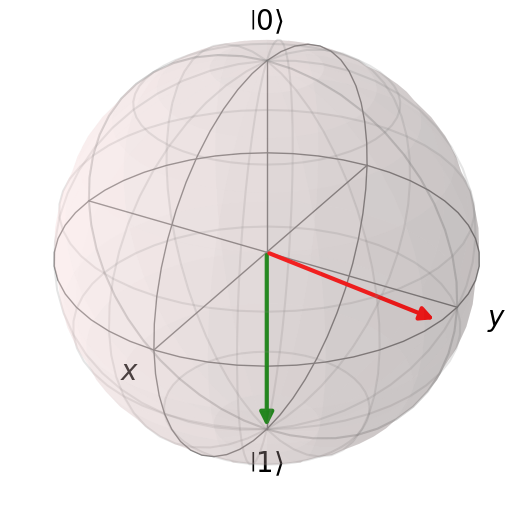

In [8]:
theta = np.pi / 2 
p = 0.9            
n = [1, 0, 0]    


psi = qec.operators.ket1()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |1>"
b.show()

## Fidelity comparison: No QEC vs Bit-flip QEC

#### (b) Noisy Bell state preparation

Now apply this formalism to simulate a noisy Bell state preparation (i.e., two qubits). After applying the Hadamard and CNOT gates to the register (to create the Bell state), apply bit flip channels to both qubits.

After this, calculate the fidelity with the perfect Bell state. The fidelity of the state is given by $$F=\sqrt{|\langle\psi|\rho|\psi\rangle|},$$
where $|\psi\rangle$ is the (pure) target state (in our case, the perfect Bell state).

Plot the fidelity as a function of $p$ to observe how the noisy Bell state preparation changes for varying the probability of having a bit flip.

Hints: 
1) Write a function that takes $p$ as an input and returns the fidelity.

2) Prepare your perfect Bell state using unitary gates.

In [9]:
initial_state = np.kron(qec.operators.ket0(), qec.operators.ket0())
H1 = np.kron(qec.operators.H, qec.operators.I)
state_after_H = H1 @ initial_state
CNOT12 = qec.operators.controlled_gate(qec.operators.X, 0, 1, 2)
psi_bell = CNOT12 @ state_after_H

print("Bell state:\n", psi_bell)

Bell state:
 [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


In [10]:
initial_state = np.kron(qec.operators.ket0(), qec.operators.ket0())
H1 = np.kron(qec.operators.H, qec.operators.I)
state_after_H = H1 @ initial_state
CNOT12 = qec.operators.controlled_gate(qec.operators.X, 0, 1, 2)
psi_bell = CNOT12 @ state_after_H
print("psi_bell:\n", psi_bell)
print()

rho_bell = qec.operators.dm(psi_bell)
kraus_2q = qec.operators.bit_flip_kraus_nqubits(p=p, n=2)
kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=p, n=3) 

kraus_2q = qec.operators.bit_flip_kraus_nqubits(p=0.9, n=2)
rho_noisy = qec.operators.apply_kraus(rho_bell, kraus_2q)

# Fidelity
F2 = np.sqrt(np.abs(np.vdot(psi_bell, rho_noisy @ psi_bell)))
print("Fidelity after 2-qubit bit-flip:\n:", F2)
print()

psi_3q = np.kron(qec.operators.ket0(), np.kron(qec.operators.ket0(), qec.operators.ket0())) 
rho_3q = qec.operators.dm(psi_3q)

kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=0.1, n=3)
rho_noisy_3q = qec.operators.apply_kraus(rho_3q, kraus_3q)


psi_ghz = (np.kron(np.kron(qec.operators.ket0(), qec.operators.ket0()), qec.operators.ket0()) +
           np.kron(np.kron(qec.operators.ket1(), qec.operators.ket1()), qec.operators.ket1())) / np.sqrt(2)
rho_ghz = qec.operators.dm(psi_ghz)

print("psi_ghz:\n", psi_ghz)
print()
print("rho_ghz:\n", rho_ghz)

kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=0.1, n=3)
rho_noisy = qec.operators.apply_kraus(rho_ghz, kraus_3q)
F3 = np.sqrt(np.abs(np.vdot(psi_ghz, rho_noisy @ psi_ghz))) 
print("Fidelity after 3-qubit bit-flip:\n:", F3)
print()

psi_bell:
 [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

Fidelity after 2-qubit bit-flip:
: 0.9055385138137416

psi_ghz:
 [0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

rho_ghz:
 [[0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]
Fidelity after 3-qubit bit-flip:
: 0.854400374531753



### Fidelity of a Noisy Bell State under Bit-Flip Noise

When preparing a **Bell state** (e.g., \(|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}\)), the presence of **bit-flip noise** can degrade its fidelity.  

- The **bit-flip channel** flips a qubit from \(|0\rangle \leftrightarrow |1\rangle\) with probability \(p\).  
- The **fidelity** of the noisy Bell state measures how close the resulting state is to the ideal Bell state.  

By varying \(p\), one can observe:

- **Low \(p\)**: fidelity remains high; the Bell state is mostly intact.  
- **High \(p\)**: fidelity decreases as more qubits are flipped, reducing entanglement and correlation.  

A plot of **fidelity vs. bit-flip probability \(p\)** shows a decreasing trend, illustrating the sensitivity of entangled states to bit-flip noise.

p      Sim(QEC)     Theory(QEC)   NoQEC
0.00    1.00000     1.00000     1.00000
0.10    0.99755     0.97200     0.90000
0.20    0.99153     0.89600     0.80000
0.30    0.98291     0.78400     0.70000
0.40    0.97301     0.64800     0.60000
0.50    0.96143     0.50000     0.50000


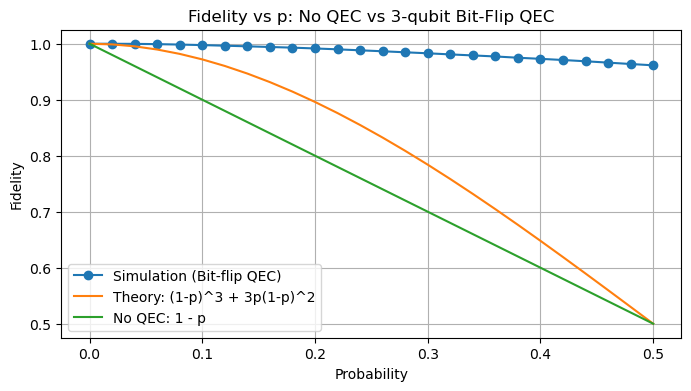

In [11]:
#parameters
alpha = 0.6
ps = np.linspace(0, 0.5, 26)
F_sim = np.array([qec.operators.avg_fidelity_bitflip_qec(p, 0.6, 4000, 1) for p in ps])
F_no_qec = 1 - ps
F_theory = (1-ps)**3 + 3*ps*(1-ps)**2  # analytical 3-qubit QEC fidelity

#results
print("p      Sim(QEC)     Theory(QEC)   NoQEC")
for i in range(0, len(ps), 5):
    print(f"{ps[i]:.2f}    {F_sim[i]:.5f}     {F_theory[i]:.5f}     {F_no_qec[i]:.5f}")

#Plot 
plt.figure(figsize=(8,4))
plt.plot(ps, F_sim, marker="o", label="Simulation (Bit-flip QEC)")
plt.plot(ps, F_theory, label="Theory: (1-p)^3 + 3p(1-p)^2")
plt.plot(ps, F_no_qec, label="No QEC: 1 - p")
plt.xlabel("Probability")
plt.ylabel("Fidelity")
plt.title("Fidelity vs p: No QEC vs 3-qubit Bit-Flip QEC")
plt.grid(True)
plt.legend()
plt.show()

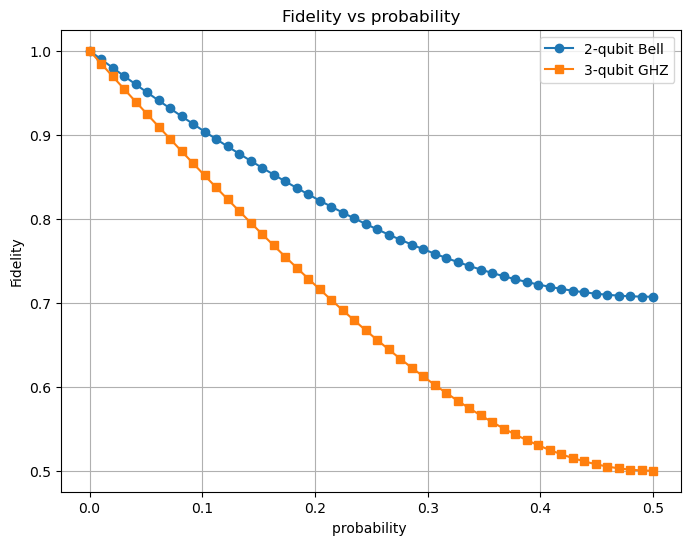

In [12]:
# Range of bit-flip probabilities
p_values = np.linspace(0, 0.5, 50)
# Prepare arrays to store fidelities
fidelity_2q = []
fidelity_3q = []

# Loop over p values
for p in p_values:
    #2-qubit Bell state 
    initial_state = np.kron(qec.operators.ket0(), qec.operators.ket0())
    H1 = np.kron(qec.operators.H, qec.operators.I)
    state_after_H = H1 @ initial_state
    CNOT12 = qec.operators.controlled_gate(qec.operators.X, 0, 1, 2)
    psi_bell = CNOT12 @ state_after_H
    rho_bell = qec.operators.dm(psi_bell)
    
    kraus_2q = qec.operators.bit_flip_kraus_nqubits(p=p, n=2)
    rho_noisy_2q = qec.operators.apply_kraus(rho_bell, kraus_2q)
    
    F2 = np.sqrt(np.abs(np.vdot(psi_bell, rho_noisy_2q @ psi_bell)))
    fidelity_2q.append(F2)
    
    #3-qubit GHZ state
    psi_ghz = (np.kron(np.kron(qec.operators.ket0(), qec.operators.ket0()), qec.operators.ket0()) +
               np.kron(np.kron(qec.operators.ket1(), qec.operators.ket1()), qec.operators.ket1())) / np.sqrt(2)
    rho_ghz = qec.operators.dm(psi_ghz)
    
    kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=p, n=3)
    rho_noisy_3q = qec.operators.apply_kraus(rho_ghz, kraus_3q)
    
    F3 = np.sqrt(np.abs(np.vdot(psi_ghz, rho_noisy_3q @ psi_ghz)))
    fidelity_3q.append(F3)

# Convert to numpy arrays
fidelity_2q = np.array(fidelity_2q)
fidelity_3q = np.array(fidelity_3q)

#plot
plt.figure(figsize=(8,6))
plt.plot(p_values, fidelity_2q, 'o-', label='2-qubit Bell')
plt.plot(p_values, fidelity_3q, 's-', label='3-qubit GHZ')
plt.xlabel("probability ")
plt.ylabel("Fidelity")
plt.title("Fidelity vs probability")
plt.grid(True)
plt.legend()
plt.show()

### Conclusion

The fidelity decreases as the bit-flip probability \(p\) increases, showing that noise degrades the prepared entangled state. The 3-qubit GHZ state loses fidelity faster than the 2-qubit Bell state because the probability of errors increases with the number of qubits. This demonstrates that larger entangled systems are more sensitive to noise.

When \(p = 0\), no bit-flip noise is applied and the fidelity is equal to 1. As the probability increases, noise introduces errors and the fidelity decreases. Around \(p = 0.5\) the state becomes highly mixed and the fidelity is lowest. For \(p = 1\), all qubits flip, but due to the symmetry of Bell and GHZ states the structure of the entangled state is preserved, leading to a higher fidelity again.